In [1]:
import pandas as pd

orders = pd.read_csv("../data/raw/amazon_retail_data.csv")
customers = pd.read_csv("../data/raw/customers.csv")
products = pd.read_csv("../data/raw/products.csv")

orders.head()

,Order_ID,Order_Date,Payment_Method,Quantity,customer_id,product_id
0,1,2025-10-09,Credit Card,1,99,32
1,2,2025-04-15,Net Banking,2,7,23
2,3,2025-02-02,UPI,1,16,33
3,4,2025-08-27,Net Banking,1,90,3
4,5,2026-07-29,Credit Card,5,60,18


Merge Tables (Build Analysis Dataset)

In [2]:
df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(products, on="product_id", how="left")

df.head()

,Order_ID,Order_Date,Payment_Method,Quantity,customer_id,product_id,customer_name,city,signup_date,product_name,category,price
0,1,2025-10-09,Credit Card,1,99,32,Customer_99,Delhi,2024-02-13,Product_32,Books,1894
1,2,2025-04-15,Net Banking,2,7,23,Customer_7,Bangalore,2024-12-16,Product_23,Books,297
2,3,2025-02-02,UPI,1,16,33,Customer_16,Bangalore,2024-08-24,Product_33,Home,759
3,4,2025-08-27,Net Banking,1,90,3,Customer_90,Delhi,2024-10-10,Product_3,Home,3099
4,5,2026-07-29,Credit Card,5,60,18,Customer_60,Bangalore,2024-09-13,Product_18,Electronics,4596


Create Sales Measure

In [3]:
df["Sales"] = df["Quantity"] * df["price"]

Basic Data Check

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Order_ID        100 non-null    int64
 1   Order_Date      100 non-null    str  
 2   Payment_Method  100 non-null    str  
 3   Quantity        100 non-null    int64
 4   customer_id     100 non-null    int64
 5   product_id      100 non-null    int64
 6   customer_name   100 non-null    str  
 7   city            100 non-null    str  
 8   signup_date     100 non-null    str  
 9   product_name    100 non-null    str  
 10  category        100 non-null    str  
 11  price           100 non-null    int64
 12  Sales           100 non-null    int64
dtypes: int64(6), str(7)
memory usage: 10.3 KB


In [5]:

df.describe()

,Order_ID,Quantity,customer_id,product_id,price,Sales
count,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000
mean,50.500000,3.120000,49.910000,26.78000,2337.290000,7050.060000
std,29.011492,1.539251,30.282873,14.30023,1358.376179,5551.786533
min,1.000000,1.000000,1.000000,1.00000,246.000000,594.000000
25%,25.750000,2.000000,24.000000,16.00000,954.000000,2352.000000
50%,50.500000,3.000000,48.000000,26.00000,2173.000000,5788.000000
75%,75.250000,5.000000,75.250000,39.25000,3396.250000,9793.000000
max,100.000000,5.000000,100.000000,50.00000,4837.000000,22980.000000


First Business KPIs

In [6]:
#Total Revenue
df["Sales"].sum()

np.int64(705006)

In [7]:
#Total Orders
df["Order_ID"].nunique()

100

In [8]:
#Total Customers
df["customer_id"].nunique()

62

In [9]:
#Total Products Sold (Units)
df["Quantity"].sum()

np.int64(312)

In [11]:
#Monthly Revenue Trend
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["YearMonth"] = df["Order_Date"].dt.to_period("M")

monthly_sales = df.groupby("YearMonth")["Sales"].sum().reset_index()
monthly_sales


,YearMonth,Sales
0,2025-01,11571
1,2025-02,39530
2,2025-03,53817
3,2025-04,42815
4,2025-05,10030
5,2025-06,38599
6,2025-07,24778
7,2025-08,57584
8,2025-09,34405
9,2025-10,18404


Visualize Trend

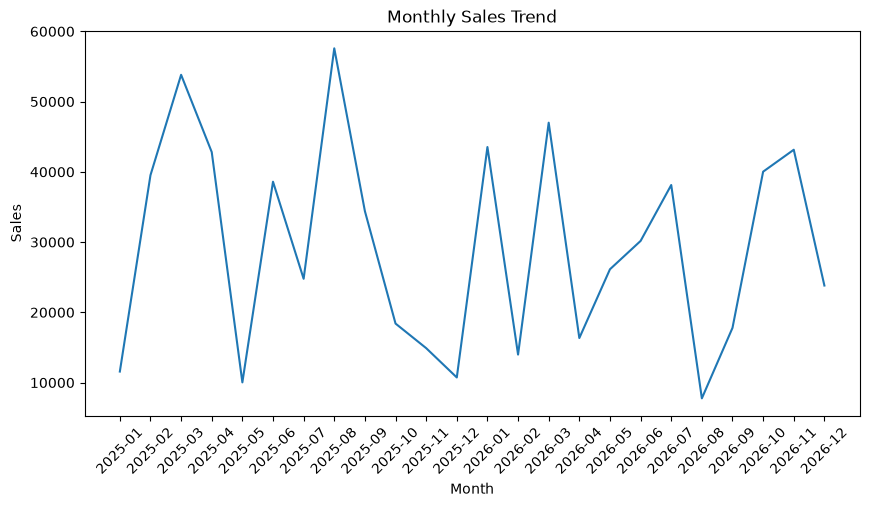

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales["YearMonth"].astype(str), monthly_sales["Sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

Top 10 Products by Revenue

In [13]:
top_products = df.groupby("product_name")["Sales"].sum().sort_values(ascending=False).head(10)
top_products

product_name
Product_50    48566
Product_25    47866
Product_2     37960
Product_22    36372
Product_17    30226
Product_40    25676
Product_30    24479
Product_16    23485
Product_18    22980
Product_32    22728
Name: Sales, dtype: int64

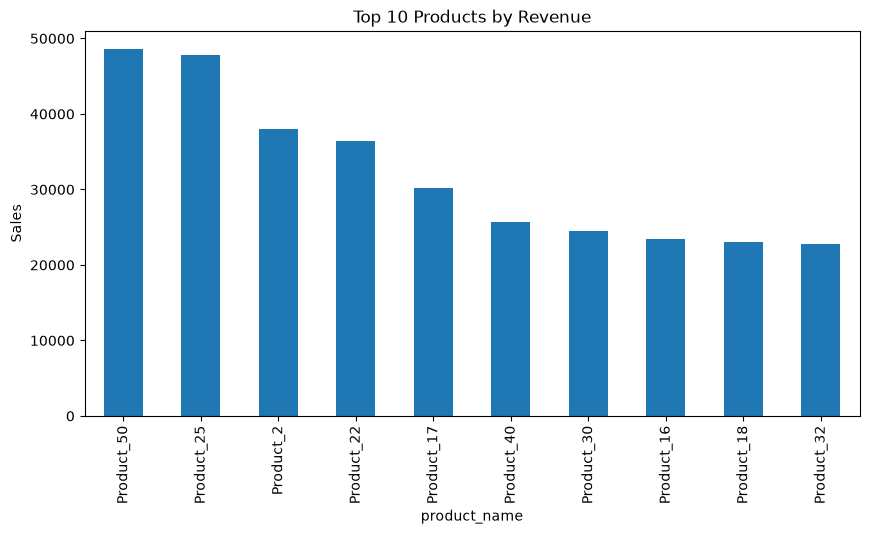

In [14]:
top_products.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Products by Revenue")
plt.ylabel("Sales")
plt.show()

Top Customers

In [15]:
top_customers = df.groupby("customer_name")["Sales"].sum().sort_values(ascending=False).head(10)
top_customers

customer_name
Customer_48    42521
Customer_60    37535
Customer_54    34950
Customer_99    31049
Customer_35    27695
Customer_33    23508
Customer_97    20462
Customer_61    19419
Customer_24    19339
Customer_37    18635
Name: Sales, dtype: int64

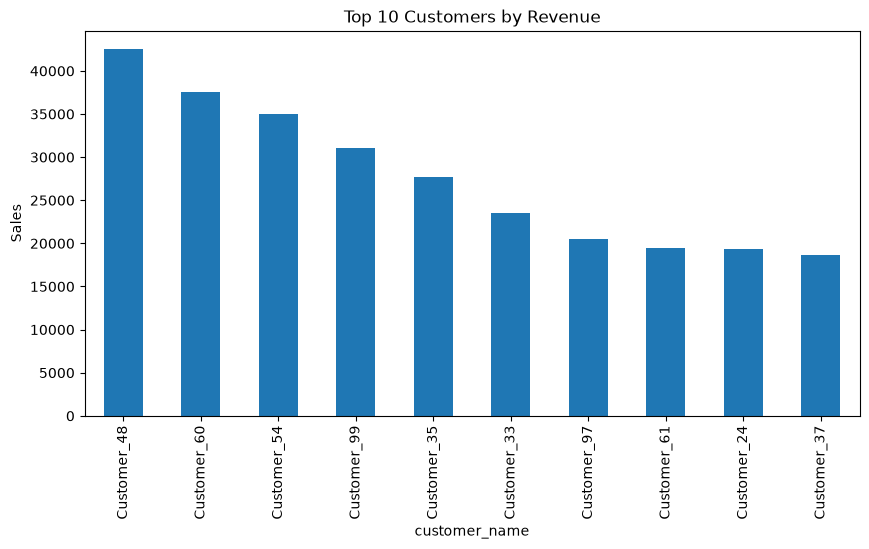

In [16]:
top_customers.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Customers by Revenue")
plt.ylabel("Sales")
plt.show()

City-wise Sales

In [17]:
city_sales = df.groupby("city")["Sales"].sum().sort_values(ascending=False)
city_sales

city
Mumbai       247971
Delhi        171808
Chennai      154687
Bangalore    130540
Name: Sales, dtype: int64

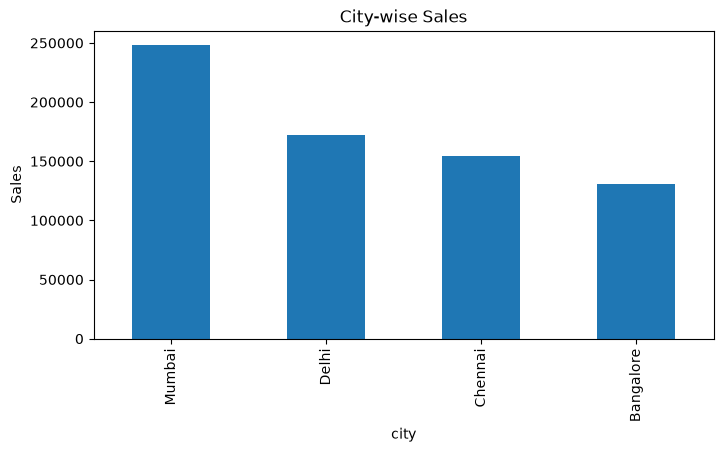

In [18]:
city_sales.plot(kind="bar", figsize=(8,4))
plt.title("City-wise Sales")
plt.ylabel("Sales")
plt.show()

Payment Method Analysis

In [19]:
payment_analysis = df.groupby("Payment_Method")["Sales"].sum()
payment_analysis

Payment_Method
Cash on Delivery     72994
Credit Card         145974
Debit Card          174131
Net Banking         141161
UPI                 170746
Name: Sales, dtype: int64

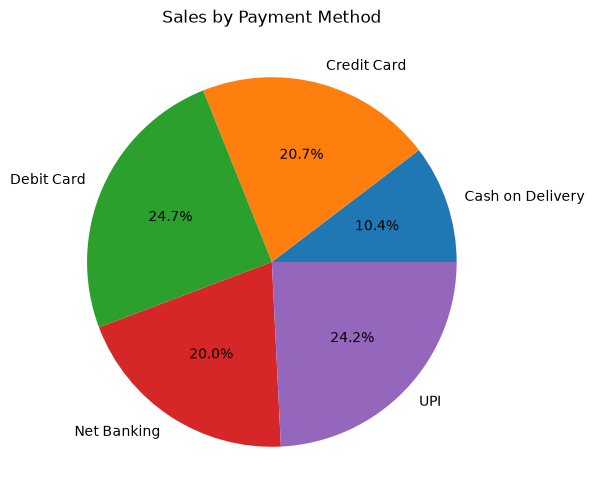

In [20]:
payment_analysis.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Sales by Payment Method")
plt.ylabel("")
plt.show()

RFM ANALYSIS (Customer Segmentation)

This is used in real companies for:
VIP customers
churn risk
loyalty programs

The snapshot_date serves as a reference point in time (essentially "today") for calculating the "Recency" metric in your RFM (Recency, Frequency, Monetary) analysis.Here is the breakdown of why this is done:1. What it calculatesIt identifies the very last order in your dataset and sets your "current date" to the day immediately following that final transaction (max() + 1 day).2. Why it is usedTo calculate Recency (how long it has been since a customer's last purchase), you need a fixed date to subtract from:$$\text{Recency} = \text{Snapshot Date} - \text{Customer's Last Purchase Date}$$3. Why add a day?If you used the exact date of the last order as your snapshot date, the most recent purchase would result in a Recency of $0$ days. By adding one day, you ensure that the most recent purchase has a Recency value of $1$ day. This makes the data more intuitive and helps avoid potential division or indexing errors when you later group or rank your customers based on recency.

In [21]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

snapshot_date = df["Order_Date"].max() + pd.Timedelta(days=1)

The .agg() function calculates three specific metrics for every customer simultaneously:

Recency ("Order_Date": lambda x: (snapshot_date - x.max()).days)

What it does: It finds the customer's most recent order date (x.max()) and subtracts it from the snapshot_date you previously defined.

Result: It tells you how many days ago the customer last made a purchase. A lower number means the customer is more active.

Frequency ("Order_ID": "count")

What it does: It counts the number of unique Order_ID entries associated with that customer.

Result: It tells you how often the customer shops. A higher number means a more loyal, repeat customer.

Monetary ("Sales": "sum")

What it does: It adds up the Sales values for every transaction the customer has ever made.

Result: It tells you the total lifetime value (LTV) of that customer. A higher number means a higher-spending customer.

In [22]:
rfm = df.groupby("customer_id").agg({
    "Order_Date": lambda x: (snapshot_date - x.max()).days,  # Recency
    "Order_ID": "count",                                      # Frequency
    "Sales": "sum"                                            # Monetary
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
1,702,1,2940
2,483,1,18410
3,22,1,11388
4,385,1,9170
6,590,1,1416


In [23]:
rfm.tail()

,Recency,Frequency,Monetary
customer_id,,,
95,134,1,8680
97,115,3,20462
98,309,1,8236
99,1,6,31049
100,128,1,1736


Score customers
1. Assigning Individual Scores (pd.qcut)The pd.qcut function divides your data into 4 equal-sized buckets (quartiles). This ensures you have an equal number of customers in each score group 
(e.g., 25% of your customers get a 1, 25% get a 2, etc.).
R_score (Recency): You used labels=[4,3,2,1].
Logic: A smaller number of days (recent) is better. So, the 25% of customers who bought most recently get a 4, and the oldest ones get a 1.
F_score (Frequency) & M_score (Monetary): You used labels=[1,2,3,4].
Logic: Higher counts/spending are better. The top 25% of customers get a 4, and the lowest get a 1.Note on Frequency: The .rank(method="first") is used to break ties. Because frequency numbers are often small integers (like 1, 2, 3), many customers will have the same value. This ensures qcut doesn't throw an error.2. Concatenating to create 
RFM_ScorePythonrfm["RFM_Score"] = rfm["R_score"].astype(str) + ...
You are turning the individual scores into a single string identifier 
(e.g., "444")."444" = The best possible customer (most recent, most frequent, highest spender).
"111" = The worst possible customer (bought a long time ago, only once, spent very little).
What to look for in rfm.head()When you run rfm.head(), you will now see three new columns for every customer. 
Here is how to interpret the results:
Segment "444": These are your Champions. You should reward them.
Segment "1xx" (Low Recency): These are At Risk. They were once customers but haven't returned in a long time.
Segment "x44" (High F/M, Low R): These are Loyalists who might have just stopped engaging—they are your prime candidates for a "We miss you" marketing campaign.

In [24]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

rfm["RFM_Score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
customer_id,,,,,,,
1,702,1,2940,1,1,1,111
2,483,1,18410,2,1,4,214
3,22,1,11388,4,1,3,413
4,385,1,9170,2,1,2,212
6,590,1,1416,1,1,1,111


rfm["Segment"] = rfm.apply(segment, axis=1)
.apply(..., axis=1): This tells pandas to run your segment function row-by-row across your rfm table.

What it does: It looks at the scores (R_score, F_score, M_score) for every individual customer and applies your logic (the if/elif/else statements you wrote) to assign them a label like "Champions," "Loyal Customers," "At Risk," or "Regular."

Result: It creates a brand new column in your rfm DataFrame called Segment that classifies every customer based on their behavior.

2. print(rfm["Segment"].value_counts())
.value_counts(): This is a powerful summary function. It counts how many customers fall into each unique category in the Segment column.

Why it's useful: It gives you an instant snapshot of your customer base. For example, it will tell you:

How many "Champions" do I have?

How many "At Risk" customers need immediate re-engagement?

Is my customer base mostly "Regular" buyers or "Loyal" repeat shoppers?

In [26]:
def segment(row):
    # Keep RFM_Score as string since you combined them
    if row["RFM_Score"] == "444":
        return "Champions"
    # Compare with integers instead of strings
    elif int(row["F_score"]) >= 3:
        return "Loyal Customers"
    elif int(row["R_score"]) <= 2:
        return "At Risk"
    else:
        return "Regular"

rfm["Segment"] = rfm.apply(segment, axis=1)
print(rfm["Segment"].value_counts())

Segment
Loyal Customers    25
At Risk            21
Regular            10
Champions           6
Name: count, dtype: int64


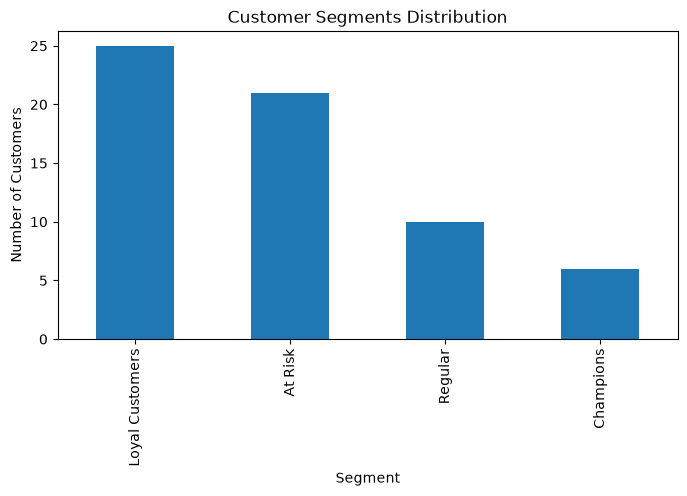

In [27]:
rfm["Segment"].value_counts().plot(kind="bar", figsize=(8,4))
plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

Segment vs Revenue (Monetary Value)

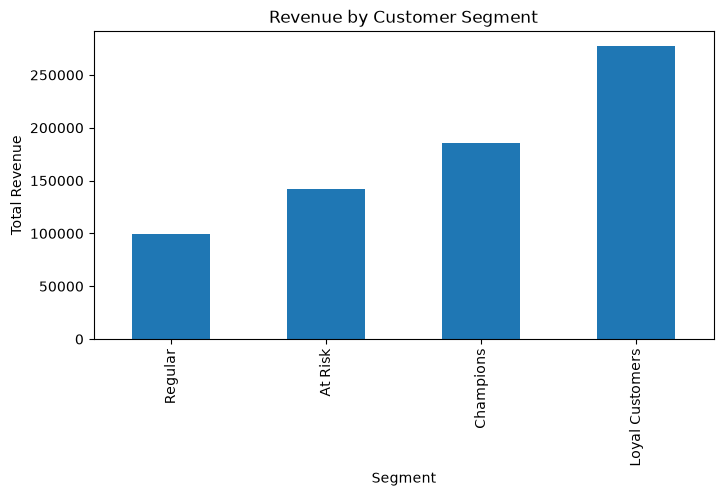

In [28]:
rfm.groupby("Segment")["Monetary"].sum().sort_values().plot(kind="bar", figsize=(8,4))
plt.title("Revenue by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")
plt.show()

Recency vs Frequency (Core RFM Insight)

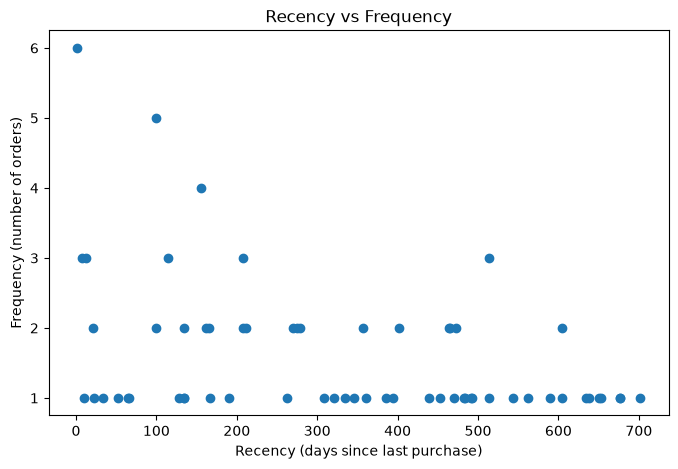

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(rfm["Recency"], rfm["Frequency"])
plt.title("Recency vs Frequency")
plt.xlabel("Recency (days since last purchase)")
plt.ylabel("Frequency (number of orders)")
plt.show()

Frequency vs Monetary

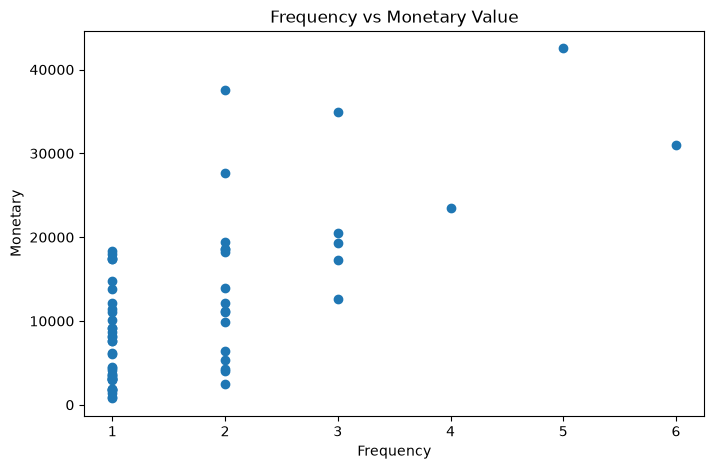

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(rfm["Frequency"], rfm["Monetary"])
plt.title("Frequency vs Monetary Value")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

In [32]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


relationship between R, F, M scores

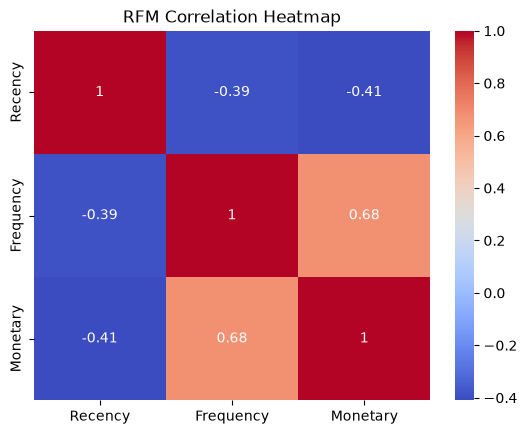

In [33]:
import seaborn as sns

rfm_scores = rfm[["Recency", "Frequency", "Monetary"]]
sns.heatmap(rfm_scores.corr(), annot=True, cmap="coolwarm")
plt.title("RFM Correlation Heatmap")
plt.show()

Plot	Insight

Segment distribution	Customer breakdown

Segment revenue	Which customers matter most

R vs F	Active vs inactive customers

F vs M	High-value behavior

Heatmap	Relationships between metrics

RFM segmentation helps identify high-value, loyal, and at-risk customers using behavioral scoring based on recency, frequency, and monetary value.”

Product Category Performance

In [34]:
category_sales = df.groupby("category")["Sales"].sum().sort_values(ascending=False)
category_sales

category
Clothing       191268
Electronics    188762
Books          163520
Home           161456
Name: Sales, dtype: int64

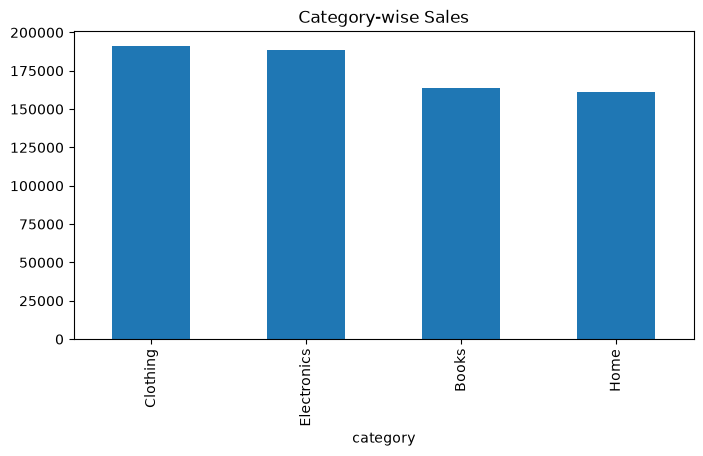

In [35]:
category_sales.plot(kind="bar", figsize=(8,4))
plt.title("Category-wise Sales")
plt.show()

80/20 Rule (Pareto Analysis)
“Do 20% of products generate 80% of revenue?”

In [36]:
product_sales = df.groupby("product_name")["Sales"].sum().sort_values(ascending=False)

Cumulative contribution

This line of code is calculating the Cumulative Percentage Contribution of your products to your total sales.

 It is the core step for performing a Pareto Analysis (often called the 80/20 Rule).
 
 Here is the breakdown of what is happening:
 
 1. The Mathproduct_sales.cumsum(): This creates a running total of your sales, sorted from highest to lowest. 
 It adds the sales of the first product to the second, then that total to the third, and so on./ 
 
 product_sales.sum(): This divides those running totals by the grand total of all sales.The Result: Each value in cum_sales now represents the percentage of total revenue accounted for by the products included up to that point.
 
 2. What cum_sales.head() shows youWhen you print .head(), you are seeing the contribution of your top-selling products. 
 
 For example:ProductCumulative ContributionProduct 
 
 A0.25 (25% of total sales)Product B0.45 (45% of total sales)Product C0.60 (60% of total sales)
 
 3. Why this is important for your project
 This analysis allows you to answer the "80/20" question: "Are 20% of my products responsible for 80% of my revenue?"If the cumulative sum reaches 0.8 quickly: You have a small group of "Hero Products" that drive the vast majority of your business. You should prioritize keeping these in stock and promoting them.If the cumulative sum grows slowly: Your revenue is spread evenly across many products, meaning your business doesn't rely on just a few "hits."

In [37]:
cum_sales = product_sales.cumsum() / product_sales.sum()
cum_sales.head()

product_name
Product_50    0.068887
Product_25    0.136782
Product_2     0.190625
Product_22    0.242216
Product_17    0.285090
Name: Sales, dtype: float64

Top contributors

In [38]:
top_20_percent = cum_sales[cum_sales <= 0.8]
top_20_percent

product_name
Product_50    0.068887
Product_25    0.136782
Product_2     0.190625
Product_22    0.242216
Product_17    0.285090
Product_40    0.321509
Product_30    0.356231
Product_16    0.389543
Product_18    0.422138
Product_32    0.454376
Product_43    0.484918
Product_46    0.514893
Product_39    0.544790
Product_7     0.574555
Product_34    0.603459
Product_6     0.632310
Product_47    0.659748
Product_24    0.685662
Product_14    0.711265
Product_45    0.735938
Product_44    0.759303
Product_35    0.780139
Name: Sales, dtype: float64

cum_sales <= 0.8: This creates a "Boolean filter." It looks at your cumulative sales percentage series and marks True for every product that is included in the first 80% of your total revenue.

cum_sales[...]: By wrapping that filter in brackets, you are extracting only the rows that meet that criteria.